In [1]:
library(tidyverse)
library(GGally)
library(car)
library(broom)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




In [14]:
players_data <- read_csv("players.csv")
players_data <- players_data %>%
    mutate(pos = factor(sub(",.*", "", position), levels = c("GK", "DF", "MF", "FW"))) %>%
    select(-position, -team_country) %>%
    filter(!is.na(goals))
head(players_data)

Rows: 1248 Columns: 13
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): team_country, position
dbl (11): age, minutes, goals, assists, cards_yellow, shots, shots_on_target...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


age,minutes,goals,assists,cards_yellow,shots,shots_on_target,fouls,offsides,interceptions,tackles_won,pos
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
23,19,0,0,0,0,0,0,1,0,0,FW
26,251,1,0,0,3,2,1,0,0,1,FW
24,98,0,0,0,2,0,0,0,1,0,MF
34,360,0,0,0,0,0,0,0,4,3,DF
23,360,0,0,1,9,3,3,1,3,5,MF
23,1,0,0,0,0,0,0,0,0,0,FW


In [15]:
players_data_log_reg <- players_data %>%
    mutate(scored=if_else(goals > 0, 1, 0)) %>%
    select(-goals)

head(players_data_log_reg)

age,minutes,assists,cards_yellow,shots,shots_on_target,fouls,offsides,interceptions,tackles_won,pos,scored
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
23,19,0,0,0,0,0,1,0,0,FW,0
26,251,0,0,3,2,1,0,0,1,FW,1
24,98,0,0,2,0,0,0,1,0,MF,0
34,360,0,0,0,0,0,0,4,3,DF,0
23,360,0,1,9,3,3,1,3,5,MF,0
23,1,0,0,0,0,0,0,0,0,FW,0


### Linear Regression

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.08,0.13,-0.63,0.53,-0.34,0.18
age,0.00,0.00,0.48,0.63,-0.01,0.01
minutes,0.00,0.00,0.57,0.57,0.00,0.00
assists,0.01,0.03,0.33,0.74,-0.04,0.06
cards_yellow,0.03,0.03,1.12,0.26,-0.03,0.10
shots,-0.01,0.01,-1.19,0.24,-0.03,0.01
shots_on_target,0.42,0.02,23.72,0.00,0.38,0.45
fouls,-0.01,0.01,-1.46,0.14,-0.03,0.00
offsides,-0.03,0.02,-1.72,0.09,-0.07,0.00


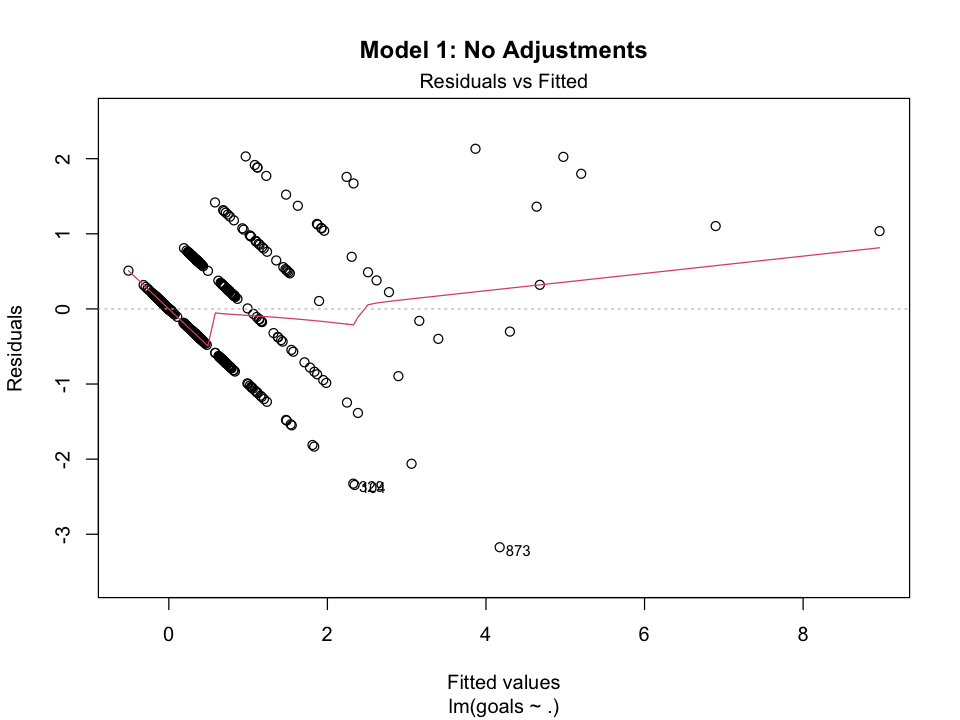

In [4]:
# lin_reg_1: original dataset
lin_reg_1 <- lm(goals ~ ., data=players_data)
lin_reg_1_results <- 
   tidy(lin_reg_1, conf.int=0.95) %>% 
   mutate_if(is.numeric, round, 2)

lin_reg_1_results

options(repr.plot.width = 8, repr.plot.height = 6) 

plot(lin_reg_1, 1, main = "Model 1: No Adjustments")

age,goals,assists,cards_yellow,shots,shots_on_target,fouls,offsides,interceptions,tackles_won,pos
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
23,0.000000000,0,0.000000000,0.00000000,0.000000000,0.000000000,0.052631579,0.000000000,0.000000000,FW
26,0.003984064,0,0.000000000,0.01195219,0.007968127,0.003984064,0.000000000,0.000000000,0.003984064,FW
24,0.000000000,0,0.000000000,0.02040816,0.000000000,0.000000000,0.000000000,0.010204082,0.000000000,MF
34,0.000000000,0,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.011111111,0.008333333,DF
23,0.000000000,0,0.002777778,0.02500000,0.008333333,0.008333333,0.002777778,0.008333333,0.013888889,MF
23,0.000000000,0,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,FW


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.00,0.00,-1.10,0.27,0.00,0.00
age,0.00,0.00,1.25,0.21,0.00,0.00
assists,-0.04,0.05,-0.84,0.40,-0.14,0.06
cards_yellow,0.03,0.01,2.47,0.01,0.01,0.06
shots,-0.01,0.01,-1.72,0.09,-0.03,0.00
shots_on_target,0.72,0.02,45.44,0.00,0.69,0.75
fouls,-0.03,0.01,-3.77,0.00,-0.05,-0.01
offsides,-0.01,0.01,-1.08,0.28,-0.03,0.01
interceptions,0.00,0.00,0.30,0.76,-0.01,0.01


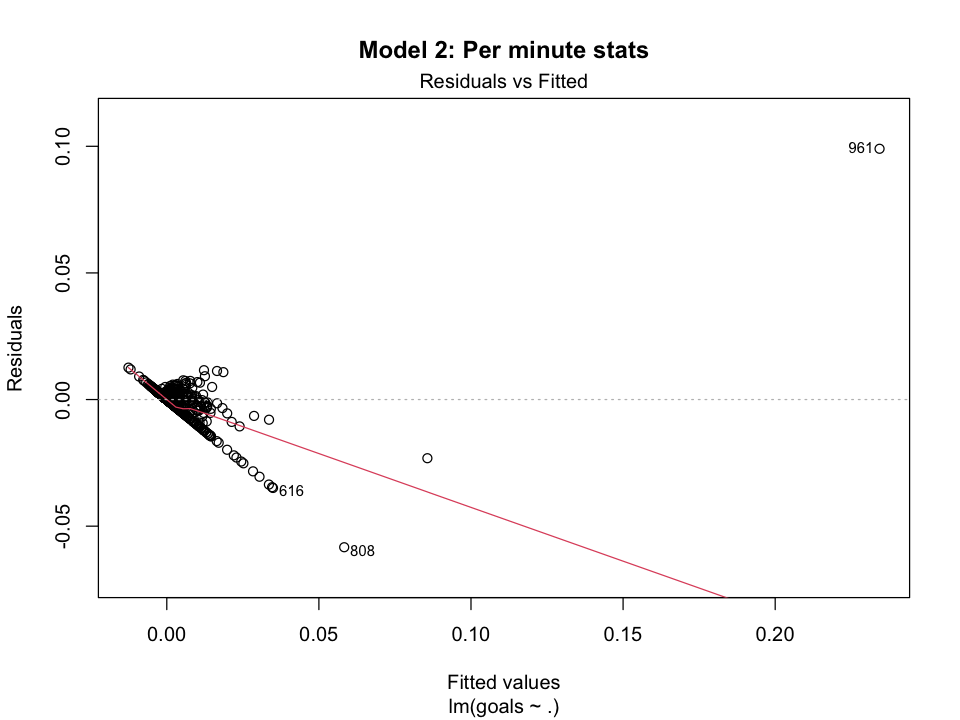

In [5]:
# lin_reg_2: original data, but just per-minute for all the stats

lin_reg_2_data <- players_data %>%
    mutate(across(c(goals, assists, cards_yellow, shots, shots_on_target, fouls, offsides, interceptions, tackles_won), ~.x/minutes)) %>%
    select(-minutes)

head(lin_reg_2_data)

lin_reg_2 <- lm(goals ~ ., data=lin_reg_2_data)
lin_reg_2_results <- 
   tidy(lin_reg_2, conf.int=0.95) %>% 
   mutate_if(is.numeric, round, 2)

lin_reg_2_results

options(repr.plot.width = 8, repr.plot.height = 6) 

plot(lin_reg_2, 1, main = "Model 2: Per minute stats")

age,goals,assists,cards_yellow,shots,shots_on_target,fouls,offsides,interceptions,tackles_won,pos
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
23,0.000000000,0,0.000000000,0.00000000,0.000000000,0.000000000,0.052631579,0.000000000,0.000000000,FW
26,0.003984064,0,0.000000000,0.01195219,0.007968127,0.003984064,0.000000000,0.000000000,0.003984064,FW
24,0.000000000,0,0.000000000,0.02040816,0.000000000,0.000000000,0.000000000,0.010204082,0.000000000,MF
34,0.000000000,0,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.011111111,0.008333333,DF
23,0.000000000,0,0.002777778,0.02500000,0.008333333,0.008333333,0.002777778,0.008333333,0.013888889,MF
23,0.000000000,0,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,FW


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.00,0.00,-1.10,0.27,0.00,0.00
age,0.00,0.00,1.25,0.21,0.00,0.00
assists,-0.04,0.05,-0.84,0.40,-0.14,0.06
cards_yellow,0.03,0.01,2.47,0.01,0.01,0.06
shots,-0.01,0.01,-1.72,0.09,-0.03,0.00
shots_on_target,0.72,0.02,45.44,0.00,0.69,0.75
fouls,-0.03,0.01,-3.77,0.00,-0.05,-0.01
offsides,-0.01,0.01,-1.08,0.28,-0.03,0.01
interceptions,0.00,0.00,0.30,0.76,-0.01,0.01


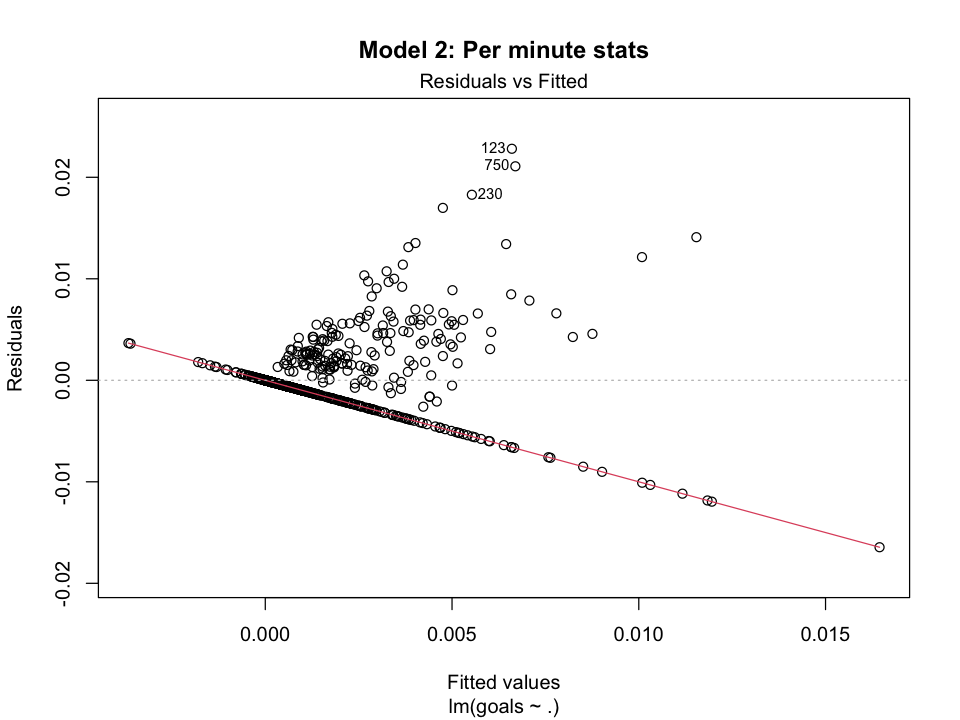

In [6]:
# lin_reg_3: original data, but just perminute for all the stats and outliers for goals scored removed

lin_reg_3_data <- players_data %>%
    mutate(across(c(goals, assists, cards_yellow, shots, shots_on_target, fouls, offsides, interceptions, tackles_won), ~.x/minutes)) %>%
    select(-minutes) %>%
    filter(goals < 0.05)

head(lin_reg_3_data)

lin_reg_3 <- lm(goals ~ ., data=lin_reg_3_data)
lin_reg_3_results <- 
   tidy(lin_reg_3, conf.int=0.95) %>% 
   mutate_if(is.numeric, round, 2)

lin_reg_3_results

options(repr.plot.width = 8, repr.plot.height = 6) 

plot(lin_reg_3, 1, main = "Model 2: Per minute stats")

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.26,0.21,-1.29,0.20,-0.67,0.14
age,0.01,0.01,0.75,0.45,-0.01,0.02
minutes,0.00,0.00,1.56,0.12,0.00,0.00
assists,-0.02,0.04,-0.61,0.54,-0.10,0.05
cards_yellow,0.00,0.05,-0.11,0.92,-0.10,0.09
shots,-0.01,0.01,-1.19,0.24,-0.04,0.01
shots_on_target,0.14,0.02,6.43,0.00,0.10,0.19
fouls,-0.01,0.01,-0.85,0.40,-0.04,0.02
offsides,-0.01,0.02,-0.57,0.57,-0.06,0.03


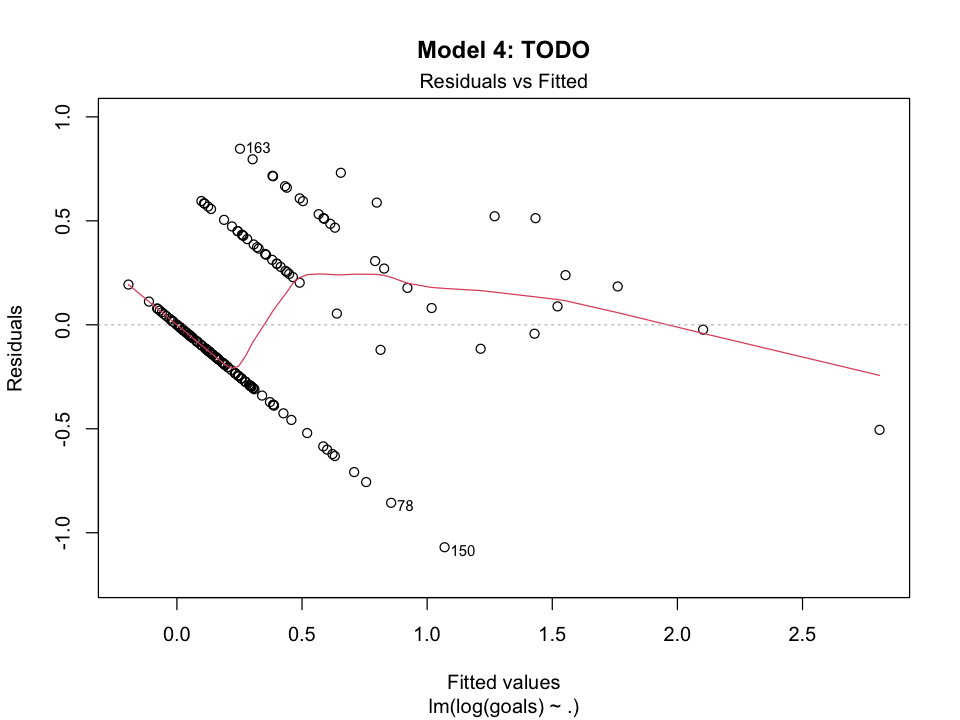

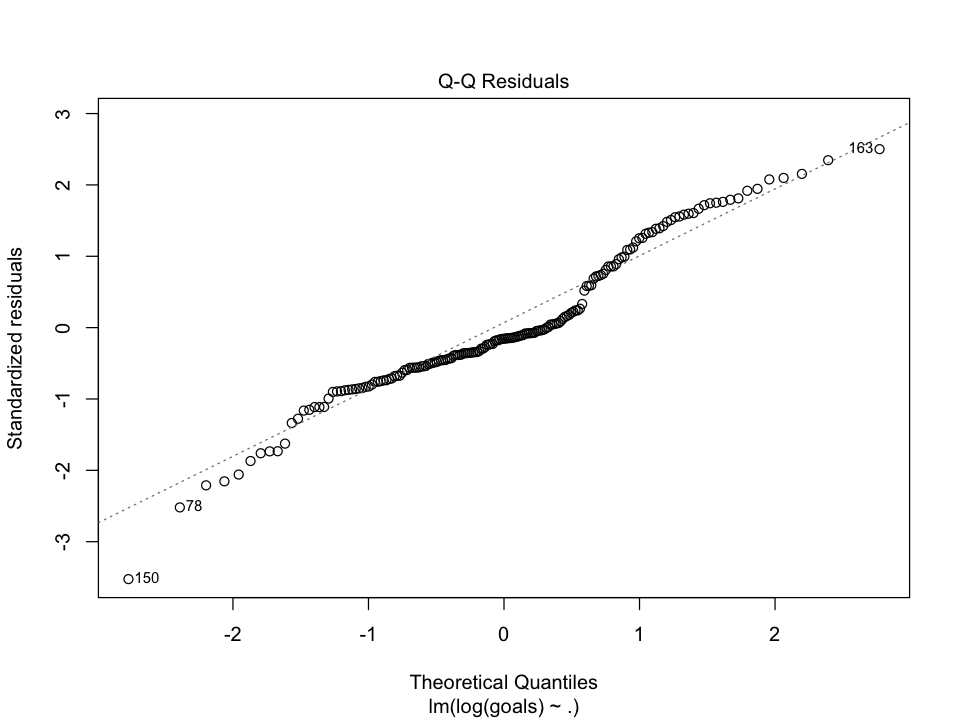

In [7]:
# lin_reg_4: original dataset but transforming the response variable using log
lin_reg_4_data <- players_data %>%
    filter(goals != 0)

lin_reg_4 <- lm(log(goals) ~ ., data=lin_reg_4_data)
lin_reg_4_results <- 
   tidy(lin_reg_4, conf.int=0.95) %>% 
   mutate_if(is.numeric, round, 2)

lin_reg_4_results

options(repr.plot.width = 8, repr.plot.height = 6) 

plot(lin_reg_4, 1, main = "Model 4: TODO")
plot(lin_reg_4, 2)

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.26,0.21,-1.29,0.20,-0.67,0.14
age,0.01,0.01,0.75,0.45,-0.01,0.02
minutes,0.00,0.00,1.56,0.12,0.00,0.00
assists,-0.02,0.04,-0.61,0.54,-0.10,0.05
cards_yellow,0.00,0.05,-0.11,0.92,-0.10,0.09
shots,-0.01,0.01,-1.19,0.24,-0.04,0.01
shots_on_target,0.14,0.02,6.43,0.00,0.10,0.19
fouls,-0.01,0.01,-0.85,0.40,-0.04,0.02
offsides,-0.01,0.02,-0.57,0.57,-0.06,0.03


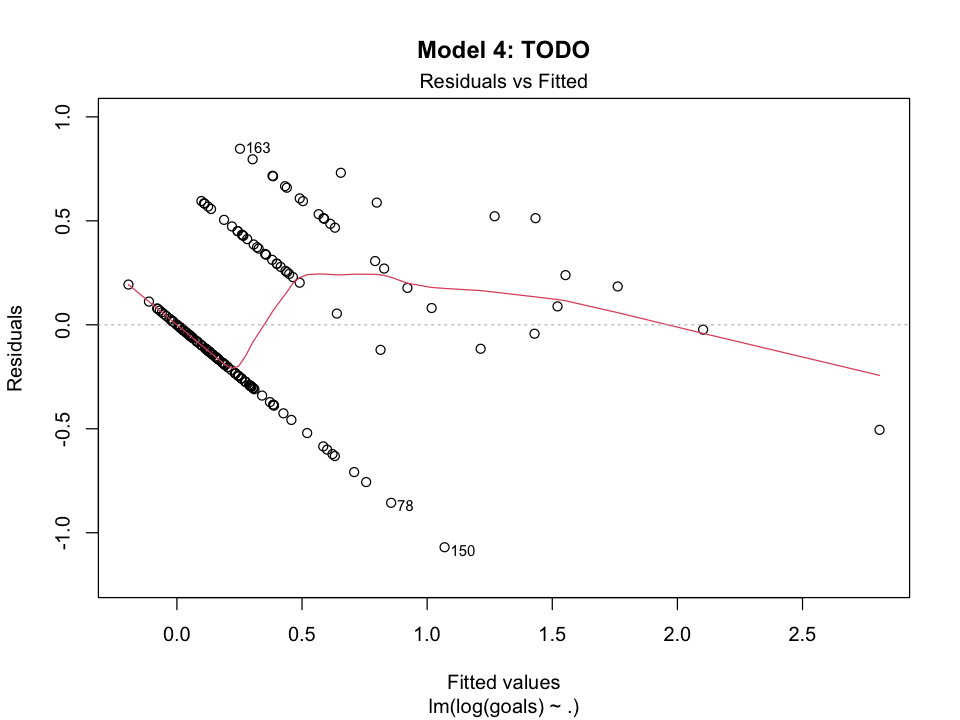

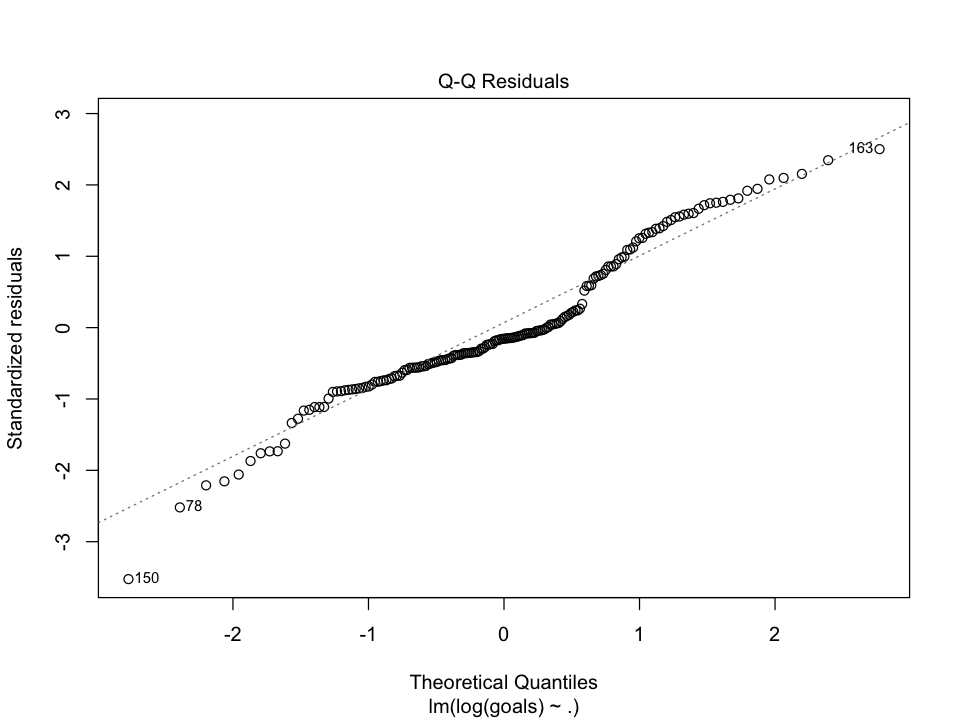

In [8]:
# lin_reg_5: normalizing for minutes and transforming the response variable using log and removing non-scorers
lin_reg_5_data <- players_data %>%
    mutate(across(c(goals, assists, cards_yellow, shots, shots_on_target, fouls, offsides, interceptions, tackles_won), ~.x/minutes)) %>%
    select(-minutes) %>%
    filter(goals != 0)

lin_reg_5 <- lm(log(goals) ~ ., data=lin_reg_4_data)
lin_reg_5_results <- 
   tidy(lin_reg_5, conf.int=0.95) %>% 
   mutate_if(is.numeric, round, 2)

lin_reg_5_results

options(repr.plot.width = 8, repr.plot.height = 6) 

plot(lin_reg_5, 1, main = "Model 4: TODO")
plot(lin_reg_5, 2)

Start:  AIC=-362.32
log(goals) ~ age + minutes + assists + cards_yellow + shots + 
    shots_on_target + fouls + offsides + interceptions + tackles_won + 
    pos

                  Df Sum of Sq    RSS     AIC
- cards_yellow     1    0.0014 20.451 -364.31
- interceptions    1    0.0023 20.452 -364.30
- pos              2    0.2339 20.684 -364.29
- offsides         1    0.0394 20.489 -363.98
- assists          1    0.0453 20.495 -363.93
- age              1    0.0698 20.520 -363.71
- fouls            1    0.0893 20.539 -363.54
- shots            1    0.1740 20.624 -362.81
<none>                         20.450 -362.32
- minutes          1    0.2984 20.748 -361.73
- tackles_won      1    0.3646 20.815 -361.16
- shots_on_target  1    5.0941 25.544 -324.51

Step:  AIC=-364.31
log(goals) ~ age + minutes + assists + shots + shots_on_target + 
    fouls + offsides + interceptions + tackles_won + pos

                  Df Sum of Sq    RSS     AIC
- pos              2    0.2328 20.684 -366.29
- 


Call:
lm(formula = log(goals) ~ shots_on_target + tackles_won, data = lin_reg_4_data)

Coefficients:
    (Intercept)  shots_on_target      tackles_won  
       -0.02432          0.12919         -0.02340  


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.02,0.04,-0.57,0.57,-0.11,0.06
shots_on_target,0.13,0.01,15.25,0.00,0.11,0.15
tackles_won,-0.02,0.01,-2.37,0.02,-0.04,0.00


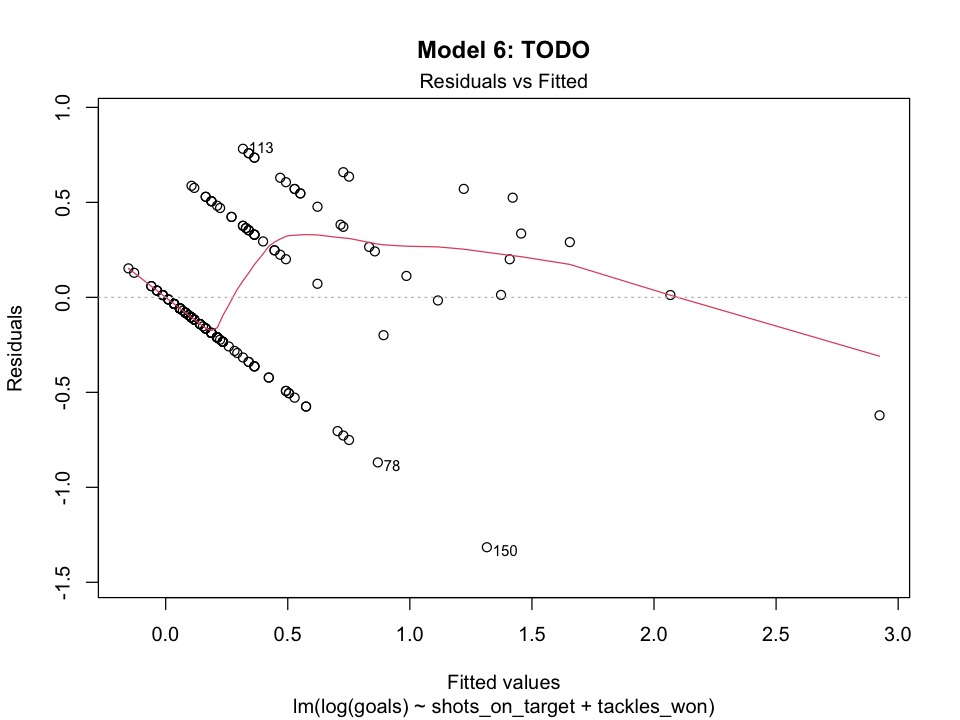

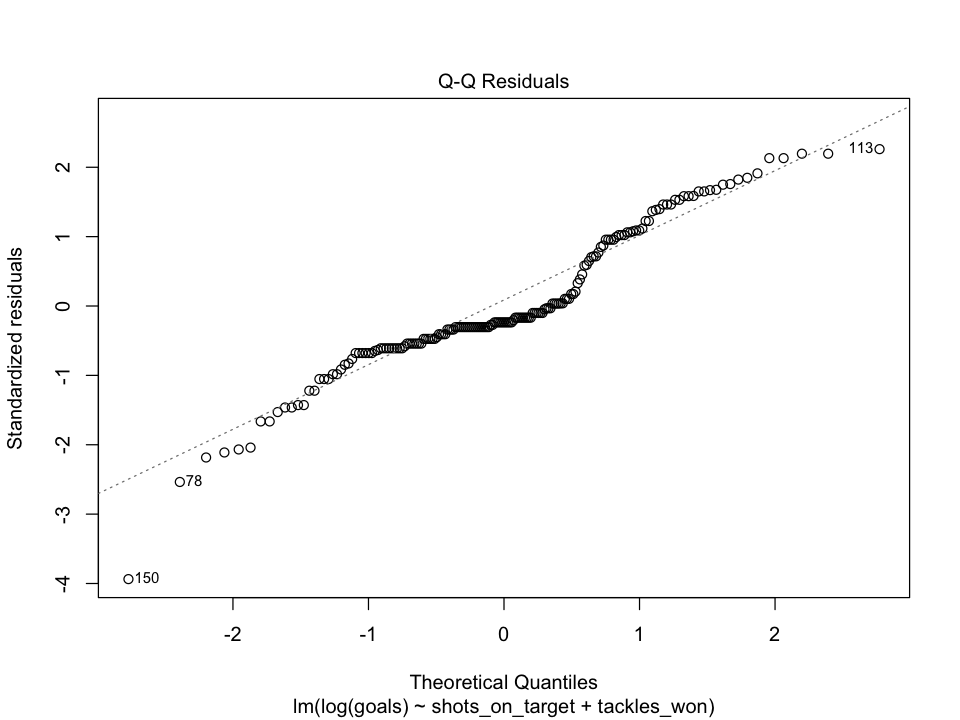

In [9]:
# lin_reg_6: normalizing for minutes and transforming the response variable using log and removing non-scorers USING STEP FUNCTION
lin_reg_6_data <- players_data %>%
    mutate(across(c(goals, assists, cards_yellow, shots, shots_on_target, fouls, offsides, interceptions, tackles_won), ~.x/minutes)) %>%
    select(-minutes) %>%
    filter(goals != 0)

lin_reg_6 <- step(lm(log(goals) ~ ., data=lin_reg_4_data))

lin_reg_6

lin_reg_6_results <- 
   tidy(lin_reg_6, conf.int=0.95) %>% 
   mutate_if(is.numeric, round, 2)

lin_reg_6_results

options(repr.plot.width = 8, repr.plot.height = 6) 

plot(lin_reg_6, 1, main = "Model 6: TODO")
plot(lin_reg_6, 2)

Start:  AIC=-362.32
log(goals) ~ age + minutes + assists + cards_yellow + shots + 
    shots_on_target + fouls + offsides + interceptions + tackles_won + 
    pos

                  Df Sum of Sq    RSS     AIC
- cards_yellow     1    0.0014 20.451 -364.31
- interceptions    1    0.0023 20.452 -364.30
- pos              2    0.2339 20.684 -364.29
- offsides         1    0.0394 20.489 -363.98
- assists          1    0.0453 20.495 -363.93
- age              1    0.0698 20.520 -363.71
- fouls            1    0.0893 20.539 -363.54
- shots            1    0.1740 20.624 -362.81
<none>                         20.450 -362.32
- minutes          1    0.2984 20.748 -361.73
- tackles_won      1    0.3646 20.815 -361.16
- shots_on_target  1    5.0941 25.544 -324.51

Step:  AIC=-364.31
log(goals) ~ age + minutes + assists + shots + shots_on_target + 
    fouls + offsides + interceptions + tackles_won + pos

                  Df Sum of Sq    RSS     AIC
- pos              2    0.2328 20.684 -366.29
- 


Call:
lm(formula = log(goals) ~ shots_on_target + tackles_won, data = lin_reg_4_data)

Coefficients:
    (Intercept)  shots_on_target      tackles_won  
       -0.02432          0.12919         -0.02340  


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.02,0.04,-0.57,0.57,-0.11,0.06
shots_on_target,0.13,0.01,15.25,0.00,0.11,0.15
tackles_won,-0.02,0.01,-2.37,0.02,-0.04,0.00


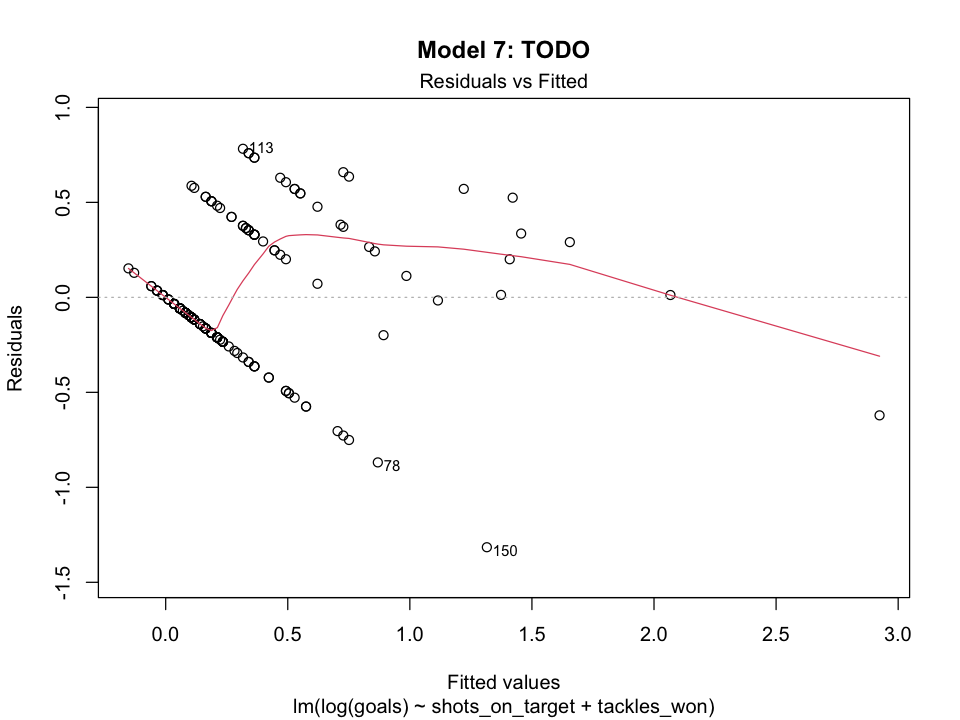

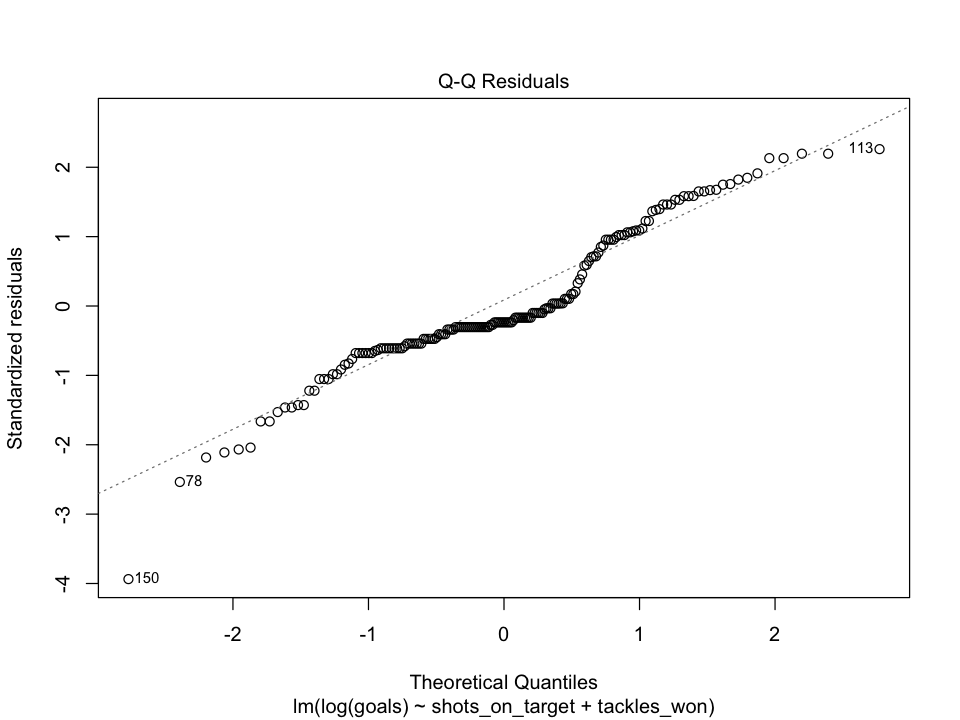

In [10]:
# lin_reg_7: original data transforming the response variable using log and removing non-scorers USING STEP FUNCTION
lin_reg_7_data <- players_data %>%
    filter(goals != 0)

lin_reg_7 <- step(lm(log(goals) ~ ., data=lin_reg_4_data))

lin_reg_7

lin_reg_7_results <- 
   tidy(lin_reg_7, conf.int=0.95) %>% 
   mutate_if(is.numeric, round, 2)

lin_reg_7_results

options(repr.plot.width = 8, repr.plot.height = 6) 

plot(lin_reg_7, 1, main = "Model 7: TODO")
plot(lin_reg_7, 2)

### Logistic Regression

In [11]:
# log_reg_1: original data 
log_reg_1 <- 
  glm(formula=scored ~ .,
      data=players_data_log_reg,
      family=binomial)

log_reg_1


Call:  glm(formula = scored ~ ., family = binomial, data = players_data_log_reg)

Coefficients:
    (Intercept)              age          minutes          assists  
     -1.702e+01       -2.675e-02        8.566e-04       -1.085e-01  
   cards_yellow            shots  shots_on_target            fouls  
      2.115e-01       -6.829e-02        1.521e+00       -4.094e-04  
       offsides    interceptions      tackles_won            posDF  
     -1.894e-01        3.030e-02       -6.504e-02        1.429e+01  
          posMF            posFW  
      1.475e+01        1.467e+01  

Degrees of Freedom: 1038 Total (i.e. Null);  1025 Residual
Null Deviance:	    954.8 
Residual Deviance: 551.8 	AIC: 579.8

In [12]:
# log_reg_1: original data using STEP FUNCTION
log_reg_2 <- 
  step(glm(formula=scored ~ .,
      data=players_data_log_reg,
      family=binomial))

log_reg_2

Start:  AIC=579.82
scored ~ age + minutes + assists + cards_yellow + shots + shots_on_target + 
    fouls + offsides + interceptions + tackles_won + pos

                  Df Deviance    AIC
- fouls            1   551.82 577.82
- interceptions    1   552.02 578.02
- assists          1   552.14 578.14
- minutes          1   552.17 578.17
- age              1   552.67 578.67
- cards_yellow     1   552.78 578.78
- tackles_won      1   552.88 578.88
- shots            1   552.95 578.95
- offsides         1   553.54 579.54
<none>                 551.82 579.82
- pos              3   558.50 580.50
- shots_on_target  1   677.44 703.44

Step:  AIC=577.82
scored ~ age + minutes + assists + cards_yellow + shots + shots_on_target + 
    offsides + interceptions + tackles_won + pos

                  Df Deviance    AIC
- interceptions    1   552.02 576.02
- assists          1   552.14 576.14
- minutes          1   552.20 576.20
- age              1   552.68 576.68
- cards_yellow     1   552.82 576.

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


                  Df Deviance    AIC
- minutes          1   553.04 573.04
- age              1   553.23 573.23
- tackles_won      1   553.33 573.33
- cards_yellow     1   553.69 573.69
- shots            1   553.74 573.74
- offsides         1   554.27 574.27
<none>                 552.35 574.35
- pos              3   559.30 575.30
- shots_on_target  1   677.53 697.53

Step:  AIC=573.04
scored ~ age + cards_yellow + shots + shots_on_target + offsides + 
    tackles_won + pos



Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


                  Df Deviance    AIC
- tackles_won      1   553.45 571.45
- age              1   553.83 571.83
- shots            1   553.94 571.94
- offsides         1   554.73 572.73
- cards_yellow     1   555.02 573.02
<none>                 553.04 573.04
- pos              3   559.31 573.31
- shots_on_target  1   680.12 698.12

Step:  AIC=571.45
scored ~ age + cards_yellow + shots + shots_on_target + offsides + 
    pos

                  Df Deviance    AIC
- age              1   554.20 570.20
- shots            1   554.68 570.68
- offsides         1   555.06 571.06
- cards_yellow     1   555.17 571.17
<none>                 553.45 571.45
- pos              3   559.87 571.87
- shots_on_target  1   681.17 697.17

Step:  AIC=570.2
scored ~ cards_yellow + shots + shots_on_target + offsides + 
    pos

                  Df Deviance    AIC
- shots            1   555.48 569.48
- cards_yellow     1   555.72 569.72
- offsides         1   556.12 570.12
<none>                 554.20 570.20
-


Call:  glm(formula = scored ~ shots_on_target + offsides + pos, family = binomial, 
    data = players_data_log_reg)

Coefficients:
    (Intercept)  shots_on_target         offsides            posDF  
       -17.5661           1.4277          -0.2055          14.2547  
          posMF            posFW  
        14.5930          14.4931  

Degrees of Freedom: 1038 Total (i.e. Null);  1033 Residual
Null Deviance:	    954.8 
Residual Deviance: 556.9 	AIC: 568.9